# Modelado de clasificación de transacciones — Hackaton Team 77

Este notebook implementa el paso posterior al EDA del proyecto de Finanzas Personales. Entrena, evalúa y exporta un clasificador para el endpoint POST /clasificar.

Decisiones metodológicas:

- Entrenamiento con transacciones sintéticas y prueba externa con las originales.
- División por descripción normalizada para impedir fuga de información.
- Predicción jerárquica: primero categoría y luego subcategoría.
- Macro F1 como métrica principal.
- Calibración de confianza en un conjunto separado.
- Revisión manual cuando la confianza es menor que 0.65.
- El perfil financiero continúa como motor de reglas auditable.


In [1]:
# 1. Configuración, versiones y rutas
from pathlib import Path
import json
import os
import re
import time
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.frozen import FrozenEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
UMBRAL_REVISION = 0.65
ARTIFACT_DIR = Path(os.getenv("TEAM77_ARTIFACT_DIR", "artifacts/modelado"))
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def resolver_csv(nombre):
    candidatos = [
        Path(nombre),
        Path("data/processed") / nombre,
        Path("inputs/Hackaton Team 77- Proyecto Finanzas Personales") / nombre,
        Path("upload") / nombre,
        Path("/content") / nombre,
    ]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    coincidencias = list(Path.cwd().rglob(nombre))
    if coincidencias:
        return coincidencias[0]
    raise FileNotFoundError(f"No se encontró {nombre}")

RUTA_DATOS = resolver_csv("dataset_clasificacion_transacciones.csv")
print(f"Python: {os.sys.version.split()[0]}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Dataset: {RUTA_DATOS.resolve()}")
print(f"Artefactos: {ARTIFACT_DIR.resolve()}")


Python: 3.12.13
scikit-learn: 1.8.0
Dataset: /workspace/scratch/023c11a88873/inputs/Hackaton Team 77- Proyecto Finanzas Personales/dataset_clasificacion_transacciones.csv
Artefactos: /workspace/scratch/023c11a88873/outputs/023c11a88873/modelo_clasificacion


In [2]:
# 2. Carga y auditoría mínima
datos = pd.read_csv(RUTA_DATOS)
requeridas = {
    "descripcion", "valor_usd", "valor_pen", "categoria",
    "subcategoria", "idioma", "es_sintetico"
}
faltantes = requeridas - set(datos.columns)
assert not faltantes, f"Faltan columnas: {sorted(faltantes)}"
assert datos[list(requeridas)].isna().sum().sum() == 0
assert (datos[["valor_usd", "valor_pen"]] >= 0).all().all()

resumen = pd.DataFrame({
    "indicador": [
        "Filas", "Categorías", "Subcategorías", "Idiomas",
        "Sintéticas", "Originales"
    ],
    "valor": [
        len(datos), datos["categoria"].nunique(), datos["subcategoria"].nunique(),
        datos["idioma"].nunique(), int(datos["es_sintetico"].sum()),
        int((~datos["es_sintetico"]).sum())
    ]
})
print(resumen.to_string(index=False))
print("\nDistribución por categoría:")
print(datos["categoria"].value_counts().to_string())


    indicador  valor
        Filas 150000
   Categorías     12
Subcategorías     46
      Idiomas      3
   Sintéticas 145900
   Originales   4100

Distribución por categoría:
categoria
Salud y bienestar    21864
Alimentación         19966
Entretenimiento      16410
Transporte           14763
Servicios            10610
Educación            10504
Regalos              10422
Compras              10344
Cuidado personal     10226
Otros                 8819
Viajes                8615
Vivienda              7457


## Preparación y división segura

El EDA mostró muchas descripciones repetidas. Una división aleatoria por fila permitiría que la misma frase aparezca en entrenamiento y prueba. Aquí cada descripción normalizada es un grupo indivisible. Las transacciones originales quedan fuera del entrenamiento.


In [3]:
# 3. Normalización y grupos únicos
def normalizar_descripcion(texto):
    texto = unicodedata.normalize("NFKD", str(texto))
    texto = texto.encode("ascii", "ignore").decode("utf-8").lower()
    texto = re.sub(r"\d+(?:[.,]\d+)?", " <num> ", texto)
    texto = re.sub(r"[^a-z<> ]+", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()

def preparar_variables_modelo(df):
    salida = df.copy()
    salida["descripcion_norm"] = salida["descripcion"].map(normalizar_descripcion)
    salida["texto_modelo"] = (
        "idioma_" + salida["idioma"].astype(str) + " " + salida["descripcion_norm"]
    )
    salida["log_valor_pen"] = np.log1p(salida["valor_pen"].clip(lower=0))
    return salida

datos_modelo = preparar_variables_modelo(datos)
sinteticos = datos_modelo.loc[datos_modelo["es_sintetico"]].copy()
originales = datos_modelo.loc[~datos_modelo["es_sintetico"]].copy()

consistencia = sinteticos.groupby("descripcion_norm").agg(
    categorias=("categoria", "nunique"),
    subcategorias=("subcategoria", "nunique")
)
assert consistencia["categorias"].max() == 1
assert consistencia["subcategorias"].max() == 1

grupos = (
    sinteticos.groupby("descripcion_norm", as_index=False)
    .agg(
        descripcion=("descripcion", "first"),
        valor_pen=("valor_pen", "median"),
        idioma=("idioma", "first"),
        categoria=("categoria", "first"),
        subcategoria=("subcategoria", "first"),
        n_filas=("categoria", "size"),
    )
)
grupos = preparar_variables_modelo(grupos)

solapamiento = len(set(originales["descripcion_norm"]) & set(grupos["descripcion_norm"]))
print(f"Descripciones sintéticas únicas: {len(grupos):,}")
print(f"Descripciones originales únicas: {originales['descripcion_norm'].nunique():,}")
print(f"Solapamiento original/sintético: {solapamiento}")


Descripciones sintéticas únicas: 8,030
Descripciones originales únicas: 48
Solapamiento original/sintético: 0


In [4]:
# 4. Split 60/10/10/20 estratificado por subcategoría
resto, prueba = train_test_split(
    grupos, test_size=0.20, random_state=RANDOM_STATE,
    stratify=grupos["subcategoria"]
)
desarrollo, calibracion = train_test_split(
    resto, test_size=0.125, random_state=RANDOM_STATE,
    stratify=resto["subcategoria"]
)
entrenamiento, validacion = train_test_split(
    desarrollo, test_size=1/7, random_state=RANDOM_STATE,
    stratify=desarrollo["subcategoria"]
)

particiones = {
    "Entrenamiento": entrenamiento,
    "Validación": validacion,
    "Calibración": calibracion,
    "Prueba": prueba,
}
nombres = list(particiones)
for i, nombre_a in enumerate(nombres):
    for nombre_b in nombres[i + 1:]:
        assert set(particiones[nombre_a]["descripcion_norm"]).isdisjoint(
            particiones[nombre_b]["descripcion_norm"]
        )

tabla_particiones = pd.DataFrame([
    {
        "partición": nombre,
        "grupos": len(df),
        "porcentaje": f"{len(df) / len(grupos):.1%}",
        "categorías": df["categoria"].nunique(),
        "subcategorías": df["subcategoria"].nunique(),
    }
    for nombre, df in particiones.items()
])
print(tabla_particiones.to_string(index=False))
print("\nControl superado: no existe solapamiento de descripciones.")


    partición  grupos porcentaje  categorías  subcategorías
Entrenamiento    4818      60.0%          12             46
   Validación     803      10.0%          12             46
  Calibración     803      10.0%          12             46
       Prueba    1606      20.0%          12             46

Control superado: no existe solapamiento de descripciones.


## Selección del modelo de categoría

Se comparan una línea base por palabras clave, TF-IDF con regresión logística y TF-IDF con LinearSVC. El idioma se incorpora como prefijo del texto y el monto como log(1 + valor_pen).


In [5]:
# 5. Línea base por palabras clave
PALABRAS_CLAVE = {
    "Alimentación": ["supermerc", "mercado", "restaurant", "restaurante", "cafe", "cafeter", "comida", "lanche", "almoco", "jantar", "bread", "fruit", "grocery"],
    "Transporte": ["taxi", "uber", "cabify", "transporte", "bus", "metro", "combust", "gasolina", "parking", "estacionamiento", "peaje", "car repair", "public transit"],
    "Vivienda": ["alquiler", "rent", "hipoteca", "mortgage", "mantenimiento del hogar", "home maintenance"],
    "Servicios": ["electric", "agua", "water bill", "internet", "telefon", "gas bill", "utility", "luz"],
    "Salud y bienestar": ["farmac", "medicine", "medic", "doctor", "dent", "odont", "gimnas", "gym", "trainer", "salud", "health", "wellness"],
    "Educación": ["educa", "matricula", "tuition", "book", "libro", "curso", "course", "learning", "school", "material escolar"],
    "Entretenimiento": ["cine", "movie", "stream", "videojuego", "game", "concert", "evento", "magazine", "revista", "lectura", "hobby"],
    "Compras": ["ropa", "clothing", "shoe", "calzado", "electron", "vehiculo", "vehicle", "car", "appliance"],
    "Regalos": ["regalo", "gift", "juguete", "toy", "joyeria", "jewelry", "flor"],
    "Viajes": ["viaje", "travel", "hotel", "vuelo", "flight", "turismo", "tourism", "alojamiento"],
    "Cuidado personal": ["higiene", "soap", "tooth", "skin", "piel", "peluquer", "hair", "personal care"],
    "Otros": ["otro", "misc"],
}

def predecir_por_palabras_clave(texto):
    normalizado = normalizar_descripcion(texto)
    puntajes = {
        categoria: sum(termino in normalizado for termino in terminos)
        for categoria, terminos in PALABRAS_CLAVE.items()
    }
    maximo = max(puntajes.values())
    return max(puntajes, key=puntajes.get) if maximo else "Otros"

pred_base = validacion["descripcion"].map(predecir_por_palabras_clave)
metrica_base = {
    "modelo": "Palabras clave",
    "accuracy_validacion": accuracy_score(validacion["categoria"], pred_base),
    "macro_f1_validacion": f1_score(
        validacion["categoria"], pred_base, average="macro"
    ),
    "segundos_entrenamiento": 0.0,
}
print(pd.DataFrame([metrica_base]).round(4).to_string(index=False))


        modelo  accuracy_validacion  macro_f1_validacion  segundos_entrenamiento
Palabras clave               0.5953               0.6474                     0.0


In [6]:
# 6. TF-IDF de palabras y caracteres + monto
def crear_preprocesador():
    return ColumnTransformer(
        transformers=[
            (
                "palabras",
                TfidfVectorizer(
                    ngram_range=(1, 2), min_df=1, max_features=30_000,
                    sublinear_tf=True, strip_accents="unicode"
                ),
                "texto_modelo",
            ),
            (
                "caracteres",
                TfidfVectorizer(
                    analyzer="char_wb", ngram_range=(3, 5), min_df=1,
                    max_features=50_000, sublinear_tf=True
                ),
                "texto_modelo",
            ),
            ("monto", StandardScaler(), ["log_valor_pen"]),
        ],
        sparse_threshold=1.0,
    )

def crear_logistica():
    return Pipeline([
        ("variables", crear_preprocesador()),
        (
            "clasificador",
            OneVsRestClassifier(
                LogisticRegression(
                    C=4.0, max_iter=500, class_weight="balanced",
                    solver="liblinear", random_state=RANDOM_STATE
                ),
                n_jobs=-1,
            ),
        ),
    ])

def crear_svc():
    return Pipeline([
        ("variables", crear_preprocesador()),
        (
            "clasificador",
            LinearSVC(
                C=2.0, class_weight="balanced", random_state=RANDOM_STATE
            ),
        ),
    ])

constructores = {
    "TF-IDF + Regresión logística": crear_logistica,
    "TF-IDF + LinearSVC": crear_svc,
}
resultados_validacion = [metrica_base]
modelos_validacion = {}

for nombre, constructor in constructores.items():
    inicio = time.perf_counter()
    modelo = constructor()
    modelo.fit(entrenamiento, entrenamiento["categoria"])
    segundos = time.perf_counter() - inicio
    pred = modelo.predict(validacion)
    modelos_validacion[nombre] = modelo
    resultados_validacion.append({
        "modelo": nombre,
        "accuracy_validacion": accuracy_score(validacion["categoria"], pred),
        "macro_f1_validacion": f1_score(
            validacion["categoria"], pred, average="macro"
        ),
        "segundos_entrenamiento": segundos,
    })

resultados_validacion = pd.DataFrame(resultados_validacion).sort_values(
    ["macro_f1_validacion", "segundos_entrenamiento"],
    ascending=[False, True],
).reset_index(drop=True)
mejor_nombre = resultados_validacion.loc[0, "modelo"]

print(resultados_validacion.round(4).to_string(index=False))
print(f"\nModelo seleccionado: {mejor_nombre}")
print("Desempate: menor tiempo cuando Macro F1 coincide.")


                      modelo  accuracy_validacion  macro_f1_validacion  segundos_entrenamiento
          TF-IDF + LinearSVC               1.0000               1.0000                  0.8626
TF-IDF + Regresión logística               1.0000               1.0000                  1.7144
              Palabras clave               0.5953               0.6474                  0.0000

Modelo seleccionado: TF-IDF + LinearSVC
Desempate: menor tiempo cuando Macro F1 coincide.


In [7]:
# 7. Modelo final de categoría y calibración
entrenamiento_final = pd.concat(
    [entrenamiento, validacion], ignore_index=True
)
modelo_categoria_base = constructores[mejor_nombre]()
modelo_categoria_base.fit(
    entrenamiento_final, entrenamiento_final["categoria"]
)

if mejor_nombre == "TF-IDF + LinearSVC":
    modelo_categoria = CalibratedClassifierCV(
        FrozenEstimator(modelo_categoria_base), method="sigmoid"
    )
    modelo_categoria.fit(calibracion, calibracion["categoria"])
    tipo_confianza = "calibración sigmoide separada"
else:
    modelo_categoria = modelo_categoria_base
    tipo_confianza = "probabilidad nativa"

pred_prueba_categoria = modelo_categoria.predict(prueba)
proba_prueba_categoria = modelo_categoria.predict_proba(prueba)
print(f"Confianza: {tipo_confianza}")
print(
    "Accuracy de categoría en prueba agrupada: "
    f"{accuracy_score(prueba['categoria'], pred_prueba_categoria):.4f}"
)
print(
    "Macro F1 de categoría en prueba agrupada: "
    f"{f1_score(prueba['categoria'], pred_prueba_categoria, average='macro'):.4f}"
)
print(
    "Confianza mediana: "
    f"{np.median(proba_prueba_categoria.max(axis=1)):.4f}"
)


Confianza: calibración sigmoide separada
Accuracy de categoría en prueba agrupada: 1.0000
Macro F1 de categoría en prueba agrupada: 1.0000
Confianza mediana: 0.9846


## Modelo jerárquico de subcategoría

Después de predecir la categoría se aplica un clasificador especializado dentro de ella. Esto evita combinaciones imposibles. Una categoría con una sola subcategoría se resuelve mediante una constante.


In [8]:
# 8. Modelos especializados de subcategoría
modelos_subcategoria = {}
subcategorias_constantes = {}

for categoria, bloque in entrenamiento_final.groupby("categoria"):
    clases = sorted(bloque["subcategoria"].unique())
    if len(clases) == 1:
        subcategorias_constantes[categoria] = clases[0]
        continue

    base = crear_svc()
    base.fit(bloque, bloque["subcategoria"])
    bloque_calibracion = calibracion.loc[
        calibracion["categoria"] == categoria
    ]
    calibrado = CalibratedClassifierCV(
        FrozenEstimator(base), method="sigmoid"
    )
    calibrado.fit(
        bloque_calibracion, bloque_calibracion["subcategoria"]
    )
    modelos_subcategoria[categoria] = calibrado

print(f"Modelos especializados: {len(modelos_subcategoria)}")
print(f"Constantes: {subcategorias_constantes}")
print("\nSubcategorías por categoría:")
print(
    entrenamiento_final.groupby("categoria")["subcategoria"]
    .nunique().sort_index().to_string()
)


Modelos especializados: 11
Constantes: {'Otros': 'Otros'}

Subcategorías por categoría:
categoria
Alimentación         4
Compras              4
Cuidado personal     3
Educación            5
Entretenimiento      6
Otros                1
Regalos              4
Salud y bienestar    6
Servicios            4
Transporte           4
Viajes               3
Vivienda             2


In [9]:
# 9. Predicción jerárquica
def predecir_jerarquico(df_entrada):
    entrada = df_entrada.reset_index(drop=True)
    pred_categoria = np.asarray(
        modelo_categoria.predict(entrada), dtype=object
    )
    proba_categoria = modelo_categoria.predict_proba(entrada)
    confianza_categoria = proba_categoria.max(axis=1)

    pred_subcategoria = np.empty(len(entrada), dtype=object)
    confianza_subcategoria = np.zeros(len(entrada), dtype=float)

    for categoria in np.unique(pred_categoria):
        posiciones = np.flatnonzero(pred_categoria == categoria)
        bloque = entrada.iloc[posiciones]
        if categoria in subcategorias_constantes:
            pred_subcategoria[posiciones] = (
                subcategorias_constantes[categoria]
            )
            confianza_subcategoria[posiciones] = 1.0
        else:
            modelo_sub = modelos_subcategoria[categoria]
            pred_subcategoria[posiciones] = modelo_sub.predict(bloque)
            confianza_subcategoria[posiciones] = (
                modelo_sub.predict_proba(bloque).max(axis=1)
            )

    confianza = np.minimum(
        confianza_categoria, confianza_subcategoria
    )
    return pd.DataFrame({
        "categoria_predicha": pred_categoria,
        "subcategoria_predicha": pred_subcategoria,
        "confianza_categoria": confianza_categoria,
        "confianza_subcategoria": confianza_subcategoria,
        "confianza": confianza,
        "requiere_revision": confianza < UMBRAL_REVISION,
    })

def evaluar_conjunto(nombre, df_evaluacion):
    pred = predecir_jerarquico(df_evaluacion)
    return {
        "conjunto": nombre,
        "filas": len(df_evaluacion),
        "descripciones_unicas": (
            df_evaluacion["descripcion_norm"].nunique()
        ),
        "accuracy_categoria": accuracy_score(
            df_evaluacion["categoria"], pred["categoria_predicha"]
        ),
        "macro_f1_categoria": f1_score(
            df_evaluacion["categoria"], pred["categoria_predicha"],
            average="macro"
        ),
        "accuracy_subcategoria": accuracy_score(
            df_evaluacion["subcategoria"],
            pred["subcategoria_predicha"]
        ),
        "macro_f1_subcategoria": f1_score(
            df_evaluacion["subcategoria"],
            pred["subcategoria_predicha"], average="macro"
        ),
        "porcentaje_revision": pred["requiere_revision"].mean(),
        "confianza_mediana": pred["confianza"].median(),
    }

grupos_prueba = set(prueba["descripcion_norm"])
sinteticos_prueba_filas = sinteticos.loc[
    sinteticos["descripcion_norm"].isin(grupos_prueba)
].copy()
originales_unicos = originales.drop_duplicates(
    "descripcion_norm"
).copy()

metricas_finales = pd.DataFrame([
    evaluar_conjunto("Sintético: grupos únicos", prueba),
    evaluar_conjunto(
        "Sintético: todas las filas de prueba",
        sinteticos_prueba_filas
    ),
    evaluar_conjunto("Original: todas las filas", originales),
    evaluar_conjunto(
        "Original: descripciones únicas", originales_unicos
    ),
])
print(metricas_finales.round(4).to_string(index=False))


                            conjunto  filas  descripciones_unicas  accuracy_categoria  macro_f1_categoria  accuracy_subcategoria  macro_f1_subcategoria  porcentaje_revision  confianza_mediana
            Sintético: grupos únicos   1606                  1606              1.0000              1.0000                 1.0000                 1.0000               0.0000             0.9386
Sintético: todas las filas de prueba  30689                  1606              1.0000              1.0000                 0.9994                 0.9993               0.0009             0.9482
           Original: todas las filas   4100                    48              0.9715              0.9781                 0.9715                 0.9684               0.0507             0.8843
      Original: descripciones únicas     48                    48              0.9792              0.9827                 0.9792                 0.9712               0.0625             0.9009


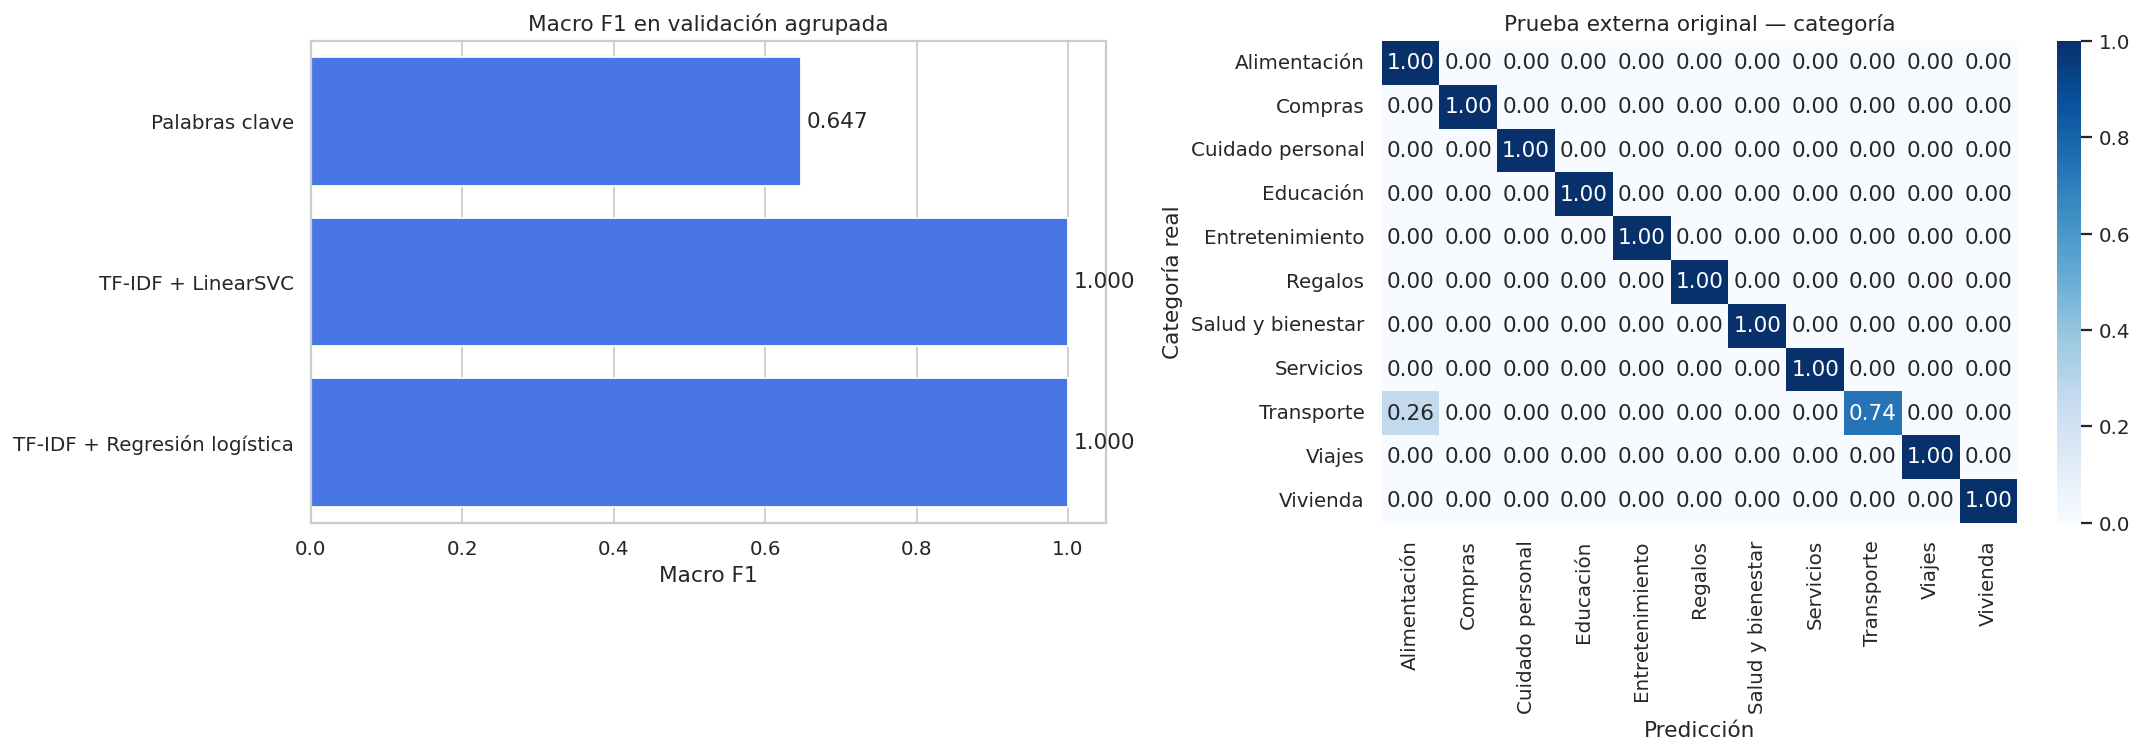

In [10]:
# 10. Comparación y matriz de confusión externa
pred_original = predecir_jerarquico(originales)
clases_categoria = sorted(originales["categoria"].unique())
matriz = confusion_matrix(
    originales["categoria"],
    pred_original["categoria_predicha"],
    labels=clases_categoria,
    normalize="true",
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
grafico = resultados_validacion.sort_values("macro_f1_validacion")
sns.barplot(
    data=grafico, x="macro_f1_validacion", y="modelo",
    color="#2F6BFF", ax=axes[0]
)
axes[0].set_xlim(0, 1.05)
axes[0].set_title("Macro F1 en validación agrupada")
axes[0].set_xlabel("Macro F1")
axes[0].set_ylabel("")
for contenedor in axes[0].containers:
    axes[0].bar_label(contenedor, fmt="%.3f", padding=3)

sns.heatmap(
    matriz, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=clases_categoria, yticklabels=clases_categoria,
    vmin=0, vmax=1, ax=axes[1]
)
axes[1].set_title("Prueba externa original — categoría")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Categoría real")
plt.tight_layout()
plt.show()


In [11]:
# 11. Auditoría de errores y umbral
pred_original_unico = predecir_jerarquico(originales_unicos)
auditoria = originales_unicos[[
    "descripcion", "categoria", "subcategoria", "idioma", "valor_pen"
]].reset_index(drop=True)
auditoria = pd.concat([auditoria, pred_original_unico], axis=1)
auditoria["subcategoria_correcta"] = (
    auditoria["subcategoria"] == auditoria["subcategoria_predicha"]
)
errores = auditoria.loc[~auditoria["subcategoria_correcta"]]

print("Errores sobre descripciones originales únicas:")
if errores.empty:
    print("No se encontraron errores.")
else:
    print(errores[[
        "descripcion", "categoria", "categoria_predicha",
        "subcategoria", "subcategoria_predicha",
        "confianza", "requiere_revision"
    ]].round(4).to_string(index=False))

print("\nPredicciones originales de menor confianza:")
print(auditoria.sort_values("confianza").head(10)[[
    "descripcion", "categoria_predicha", "subcategoria_predicha",
    "confianza", "requiere_revision"
]].round(4).to_string(index=False))

alta_confianza = ~pred_original["requiere_revision"]
originales_evaluacion = originales.reset_index(drop=True)
precision_automatica = accuracy_score(
    originales_evaluacion.loc[alta_confianza, "subcategoria"],
    pred_original.loc[alta_confianza, "subcategoria_predicha"],
)
print(f"\nUmbral: {UMBRAL_REVISION:.2f}")
print(
    "Filas originales derivadas a revisión: "
    f"{pred_original['requiere_revision'].mean():.2%}"
)
print(
    "Exactitud de subcategoría aceptada automáticamente: "
    f"{precision_automatica:.2%}"
)


Errores sobre descripciones originales únicas:
descripcion  categoria categoria_predicha subcategoria subcategoria_predicha  confianza  requiere_revision
        Gas Transporte       Alimentación  Combustible          Supermercado     0.6199               True

Predicciones originales de menor confianza:
descripcion categoria_predicha subcategoria_predicha  confianza  requiere_revision
      Shoes            Compras               Calzado     0.6078               True
 Gift Cards            Regalos     Tarjeta de regalo     0.6123               True
        Gas       Alimentación          Supermercado     0.6199               True
Electronics            Compras           Electrónica     0.6825              False
      Books          Educación                Libros     0.7248              False
       Soap   Cuidado personal               Higiene     0.7300              False
 Water Bill          Servicios                  Agua     0.7554              False
   Magazine    Entretenimiento

In [12]:
# 12. Reportes detallados de categoría
print("PRUEBA SINTÉTICA AGRUPADA")
print(classification_report(
    prueba["categoria"],
    predecir_jerarquico(prueba)["categoria_predicha"],
    digits=4, zero_division=0
))

print("PRUEBA EXTERNA ORIGINAL")
print(classification_report(
    originales["categoria"],
    pred_original["categoria_predicha"],
    digits=4, zero_division=0
))


PRUEBA SINTÉTICA AGRUPADA
                   precision    recall  f1-score   support

     Alimentación     1.0000    1.0000    1.0000       393
          Compras     1.0000    1.0000    1.0000       100
 Cuidado personal     1.0000    1.0000    1.0000       116
        Educación     1.0000    1.0000    1.0000       137
  Entretenimiento     1.0000    1.0000    1.0000       187
            Otros     1.0000    1.0000    1.0000        78
          Regalos     1.0000    1.0000    1.0000        96
Salud y bienestar     1.0000    1.0000    1.0000       175
        Servicios     1.0000    1.0000    1.0000        97
       Transporte     1.0000    1.0000    1.0000       101
           Viajes     1.0000    1.0000    1.0000        74
         Vivienda     1.0000    1.0000    1.0000        52

         accuracy                         1.0000      1606
        macro avg     1.0000    1.0000    1.0000      1606
     weighted avg     1.0000    1.0000    1.0000      1606

PRUEBA EXTERNA ORIGINAL
   

## Exportación para la API

El bundle contiene los modelos, constantes, clases, umbral y métricas. La API deberá aplicar la misma normalización antes de inferir.


In [13]:
# 13. Exportar bundle validado
metricas_serializables = metricas_finales.copy()
bundle = {
    "version": "1.0.0",
    "proyecto": "Hackaton Team 77 - Finanzas Personales",
    "random_state": RANDOM_STATE,
    "umbral_revision": UMBRAL_REVISION,
    "campos_entrada": ["descripcion", "valor_pen", "idioma"],
    "modelo_categoria": modelo_categoria,
    "modelos_subcategoria": modelos_subcategoria,
    "subcategorias_constantes": subcategorias_constantes,
    "clases_categoria": list(modelo_categoria.classes_),
    "metricas": metricas_serializables.to_dict(orient="records"),
    "nota": (
        "Entrenado con grupos sintéticos; originales reservados "
        "como prueba externa."
    ),
}

RUTA_MODELO = (
    ARTIFACT_DIR /
    "modelo_clasificacion_transacciones_team77.joblib"
)
joblib.dump(bundle, RUTA_MODELO, compress=3)
bundle_recargado = joblib.load(RUTA_MODELO)
assert bundle_recargado["version"] == bundle["version"]
assert set(bundle_recargado["clases_categoria"]) == set(
    bundle["clases_categoria"]
)

print(f"Modelo exportado: {RUTA_MODELO.resolve()}")
print(
    f"Tamaño: {RUTA_MODELO.stat().st_size / (1024 ** 2):.2f} MB"
)
print(f"Categorías: {len(bundle['clases_categoria'])}")
print(
    "Modelos de subcategoría: "
    f"{len(bundle['modelos_subcategoria'])}"
)


Modelo exportado: /workspace/scratch/023c11a88873/outputs/023c11a88873/modelo_clasificacion/modelo_clasificacion_transacciones_team77.joblib
Tamaño: 0.58 MB
Categorías: 12
Modelos de subcategoría: 11


In [14]:
# 14. Inferencia equivalente a POST /clasificar
def clasificar_transaccion(
    descripcion, valor_pen, idioma="es", bundle_modelo=None
):
    b = bundle if bundle_modelo is None else bundle_modelo
    entrada = pd.DataFrame([{
        "descripcion": descripcion,
        "valor_pen": float(valor_pen),
        "idioma": idioma,
    }])
    entrada = preparar_variables_modelo(entrada)

    modelo_cat = b["modelo_categoria"]
    categoria = modelo_cat.predict(entrada)[0]
    confianza_cat = float(
        modelo_cat.predict_proba(entrada)[0].max()
    )

    if categoria in b["subcategorias_constantes"]:
        subcategoria = b["subcategorias_constantes"][categoria]
        confianza_sub = 1.0
    else:
        modelo_sub = b["modelos_subcategoria"][categoria]
        subcategoria = modelo_sub.predict(entrada)[0]
        confianza_sub = float(
            modelo_sub.predict_proba(entrada)[0].max()
        )

    confianza = min(confianza_cat, confianza_sub)
    return {
        "categoria": str(categoria),
        "subcategoria": str(subcategoria),
        "confianza": round(confianza, 4),
        "requiere_revision": bool(
            confianza < b["umbral_revision"]
        ),
        "version_modelo": b["version"],
    }

ejemplos = [
    {
        "descripcion": "Pago mensual de electricidad",
        "valor_pen": 145.50, "idioma": "es"
    },
    {
        "descripcion": "Taxi por aplicativo",
        "valor_pen": 28.00, "idioma": "es"
    },
    {
        "descripcion": "Compra de medicamentos en farmacia",
        "valor_pen": 87.40, "idioma": "es"
    },
    {
        "descripcion": "Gas",
        "valor_pen": 240.32, "idioma": "en"
    },
]

for ejemplo in ejemplos:
    respuesta = clasificar_transaccion(
        **ejemplo, bundle_modelo=bundle_recargado
    )
    print(json.dumps(
        {"entrada": ejemplo, "respuesta": respuesta},
        ensure_ascii=False, indent=2
    ))


{
  "entrada": {
    "descripcion": "Pago mensual de electricidad",
    "valor_pen": 145.5,
    "idioma": "es"
  },
  "respuesta": {
    "categoria": "Servicios",
    "subcategoria": "Electricidad",
    "confianza": 0.6907,
    "requiere_revision": false,
    "version_modelo": "1.0.0"
  }
}
{
  "entrada": {
    "descripcion": "Taxi por aplicativo",
    "valor_pen": 28.0,
    "idioma": "es"
  },
  "respuesta": {
    "categoria": "Transporte",
    "subcategoria": "Taxi y aplicativo",
    "confianza": 0.9488,
    "requiere_revision": false,
    "version_modelo": "1.0.0"
  }
}
{
  "entrada": {
    "descripcion": "Compra de medicamentos en farmacia",
    "valor_pen": 87.4,
    "idioma": "es"
  },
  "respuesta": {
    "categoria": "Salud y bienestar",
    "subcategoria": "Farmacia",
    "confianza": 0.94,
    "requiere_revision": false,
    "version_modelo": "1.0.0"
  }
}
{
  "entrada": {
    "descripcion": "Gas",
    "valor_pen": 240.32,
    "idioma": "en"
  },
  "respuesta": {
    "categor

In [15]:
# 15. Resumen ejecutivo
fila_sintetica = metricas_finales.loc[
    metricas_finales["conjunto"] == "Sintético: grupos únicos"
].iloc[0]
fila_original = metricas_finales.loc[
    metricas_finales["conjunto"] == "Original: todas las filas"
].iloc[0]

print("RESUMEN DEL MODELADO")
print(f"- Modelo: {mejor_nombre}")
print(
    "- Macro F1 categoría, prueba sintética: "
    f"{fila_sintetica['macro_f1_categoria']:.4f}"
)
print(
    "- Macro F1 subcategoría, prueba sintética: "
    f"{fila_sintetica['macro_f1_subcategoria']:.4f}"
)
print(
    "- Macro F1 categoría, prueba original: "
    f"{fila_original['macro_f1_categoria']:.4f}"
)
print(
    "- Macro F1 subcategoría, prueba original: "
    f"{fila_original['macro_f1_subcategoria']:.4f}"
)
print(f"- Umbral de revisión: {UMBRAL_REVISION:.2f}")
print("- Riesgo observado: frases cortas y ambiguas, como Gas.")
print("- Artefacto listo para una API Python.")


RESUMEN DEL MODELADO
- Modelo: TF-IDF + LinearSVC
- Macro F1 categoría, prueba sintética: 1.0000
- Macro F1 subcategoría, prueba sintética: 1.0000
- Macro F1 categoría, prueba original: 0.9781
- Macro F1 subcategoría, prueba original: 0.9684
- Umbral de revisión: 0.65
- Riesgo observado: frases cortas y ambiguas, como Gas.
- Artefacto listo para una API Python.


## Conclusiones

- La separación por descripción evita métricas infladas por repetición.
- La prueba sintética mide aprendizaje de plantillas; la original es la referencia de generalización.
- La revisión por baja confianza evita automatizar frases ambiguas.
- El artefacto está listo para una API Python con POST /clasificar.
- Antes de producción se debe ampliar el conjunto original, especialmente con transacciones reales de Perú y ejemplos ambiguos por idioma.
